EXERCICIO 1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

 Plote um gr´afico de linhas da quantidade de vendas diarias.

In [3]:
df_vendas = pd.read_excel(r"C:\Users\58112784892\Desktop\Ciência de Dados - Gabriel Borges\Estrutura de Dados\ANALISE_DE_DADOS\dados_vendas.xlsx")
df_vendas

,Data,Quantidade Vendida
0,2022-01-01,102
1,2022-01-02,102
2,2022-01-03,107
3,2022-01-04,102
4,2022-01-05,104
...,...,...
360,2022-12-27,113
361,2022-12-28,109
362,2022-12-29,111
363,2022-12-30,113


<Axes: >

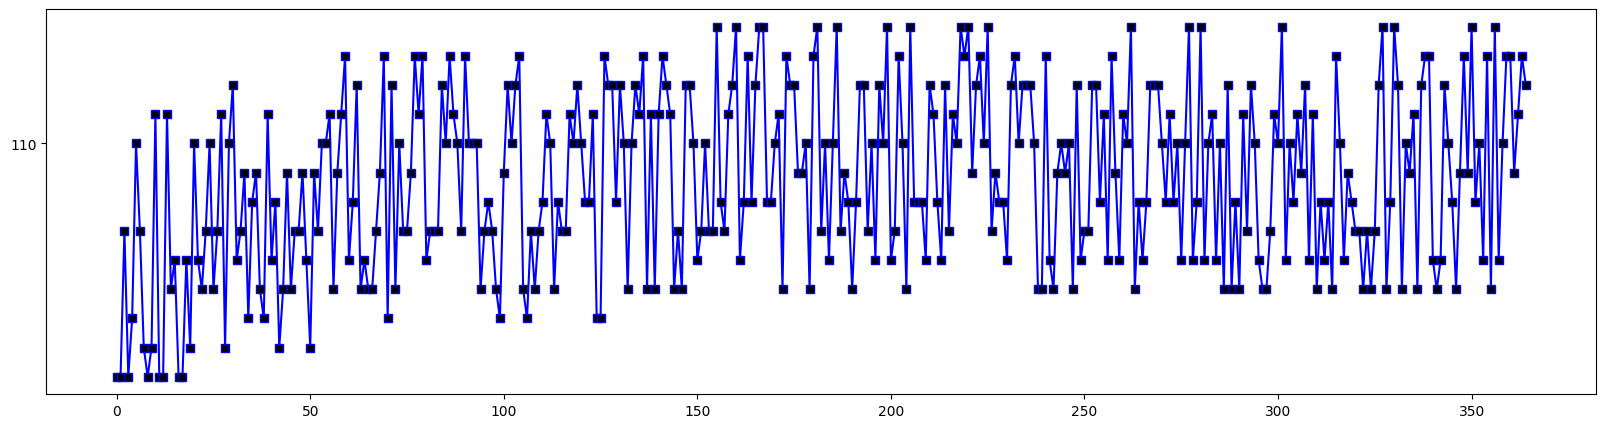

In [4]:
plt.figure(figsize=(20,5))
plt.yticks(range(0,141,10))
df_vendas["Quantidade Vendida"].plot(marker='s', linestyle='-',color='blue',mfc="black")


 Identifique o dia com o maior n´umero de vendas e o valor correspondente. • Identifique
o dia com o menor n´umero de vendas e o valor correspondente. • Calcule o valor m´edio
das vendas di´arias ao longo do ano.

In [8]:
dia_maior = df_vendas["Quantidade Vendida"].max()
print(dia_maior)
dia_indx_maior = df_vendas["Quantidade Vendida"].idxmax()
print(dia_indx_maior)
df_vendas["Data"] = pd.to_datetime(df_vendas["Data"])
print(f"Maior venda em um dia foi: {dia_maior}, no dia {df_vendas["Data"][dia_indx_maior]}")

114
155
Maior venda em um dia foi: 114, no dia 2022-06-05 00:00:00


In [21]:
dia_menor = df_vendas["Quantidade Vendida"].min()
print(dia_menor)
dia_indx_menor = df_vendas["Quantidade Vendida"].idxmin()
print(dia_indx_menor)
df_vendas["Data"] = pd.to_datetime(df_vendas["Data"])
print(f"A menor venda em um dia foi: {dia_menor}, no dia: {df_vendas["Data"][dia_indx_menor]}")

102
0
A menor venda em um dia foi: 102, no dia: 2022-01-01 00:00:00


In [15]:
dia_media = df_vendas["Quantidade Vendida"].mean().astype(int)
dia_media
print(f"O valor médio das vendas diárias ao longo do ano {dia_media}")

O valor médio das vendas diárias ao longo do ano 108


Text(0, 0.5, 'Quantidade de Vendas')

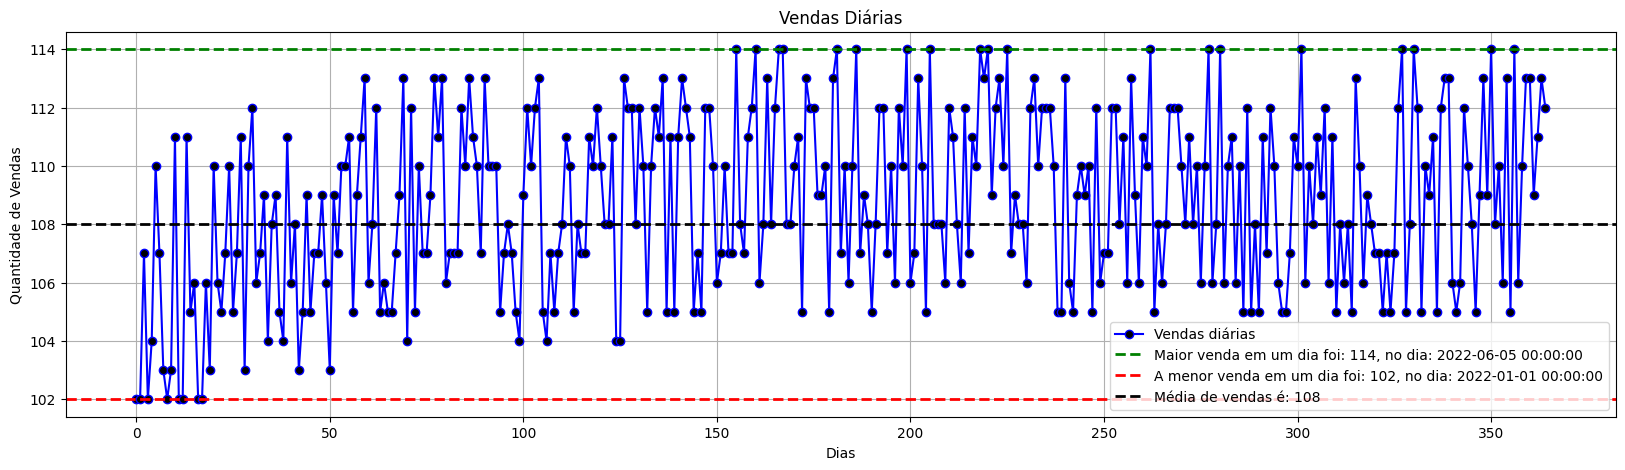

In [27]:
plt.figure(figsize=(20,5))
df_vendas["Quantidade Vendida"].plot(marker="o",linestyle="-",color="blue",label="Vendas diárias",mfc="black")
plt.grid(True)

plt.axhline(y=dia_maior,color="green",linestyle="--",linewidth=2,label=f"Maior venda em um dia foi: {dia_maior}, no dia: {df_vendas["Data"][dia_indx_maior]}")
plt.axhline(
    y=dia_menor, color="red", linestyle="--", linewidth=2,
    label=f"A menor venda em um dia foi: {dia_menor}, no dia: {df_vendas['Data'][dia_indx_menor]}"
)
plt.axhline(
    y=dia_media, color="black", linestyle="--",linewidth=2,
    label=f"Média de vendas é: {dia_media}"
)
plt.legend()

plt.title("Vendas Diárias")
plt.xlabel("Dias")
plt.ylabel("Quantidade de Vendas")

EXERCICIO 2

Media Mensal de Vendas
• Agrupe os dados por mes e calcule a media de vendas para cada mes. 
• Plote um grafico de barras mostrando a media de vendas mensais.
• Analise se ha variacao significativa entre os meses e proponha uma possıvel

In [31]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Data                365 non-null    datetime64[us]
 1   Quantidade Vendida  365 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 5.8 KB


In [32]:
df_vendas["Mês"] = df_vendas["Data"].dt.to_period("M")
df_vendas

,Data,Quantidade Vendida,Mês
0,2022-01-01,102,2022-01
1,2022-01-02,102,2022-01
2,2022-01-03,107,2022-01
3,2022-01-04,102,2022-01
4,2022-01-05,104,2022-01
...,...,...,...
360,2022-12-27,113,2022-12
361,2022-12-28,109,2022-12
362,2022-12-29,111,2022-12
363,2022-12-30,113,2022-12


In [38]:
media_mensal = df_vendas.groupby("Mês")["Quantidade Vendida"].mean().astype(int)
media_mensal

Mês
2022-01    105
2022-02    107
2022-03    108
2022-04    108
2022-05    109
2022-06    109
2022-07    109
2022-08    109
2022-09    109
2022-10    108
2022-11    108
2022-12    109
Freq: M, Name: Quantidade Vendida, dtype: int64

In [ ]:
# Transformar em data frame
media_mensal = media_mensal.reset_index()
media_mensal


,Mês,Quantidade Vendida
0,2022-01,105
1,2022-02,107
2,2022-03,108
3,2022-04,108
4,2022-05,109
5,2022-06,109
6,2022-07,109
7,2022-08,109
8,2022-09,109
9,2022-10,108


In [50]:
maior_media = media_mensal["Quantidade Vendida"].max()

Text(0, 0.5, 'Quantidade de Vendas')

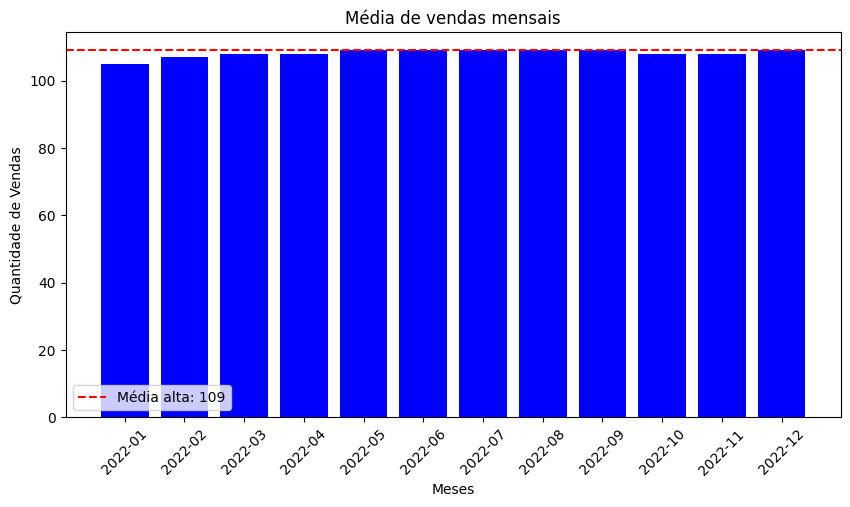

In [56]:
plt.figure(figsize=(10,5))
plt.bar(media_mensal["Mês"].astype(str), media_mensal["Quantidade Vendida"],color="blue")
plt.xticks(rotation=45)
plt.axhline(y=maior_media,color="red",linestyle="--",label=f"Média alta: {maior_media}")
plt.legend()
plt.title("Média de vendas mensais")
plt.xlabel('Meses')
plt.ylabel("Quantidade de Vendas")

**Analise de Variacao**


A variação ao longo do ano é relativamente baixa, indicando certa estabilidade nas vendas. No entanto, é possível observar um leve aumento no período intermediário, entre os meses 4 e 8, além de um novo pico em dezembro.

Esse comportamento pode ser explicado por fatores sazonais. No meio do ano, o aumento pode estar relacionado a datas comemorativas, clima (dependendo do tipo de produto) ou até períodos de férias, que costumam impulsionar o consumo. Já em dezembro, o crescimento é esperado devido às festas de fim de ano, como o Natal, quando há um aumento significativo na demanda.

Diante disso, uma boa estratégia seria intensificar a divulgação e ações promocionais nesses períodos de maior potencial. Além disso, é importante reforçar o estoque dos produtos mais vendidos, garantindo que a empresa consiga atender ao aumento da demanda sem perder oportunidades de venda.